# 02 | Data Preprocessing

**Author:** Nguyen (Sue) Huynh  
**Last Updated:** June 2026

---

**Objectives**

This notebook prepares the Criteo Uplift Dataset for meta-learner training. 
Building on insights from `01_eda.ipynb`, we apply targeted transformations 
to address distributional issues identified during exploration and produce a 
clean, model-ready dataset saved to disk for all downstream notebooks.


## 1. Setup and Data Loading

We initialize the `Preprocessor` class, which composes a `DataLoader` instance to handle data ingestion and uses a `FunctionTransformer` for log transformation. The `Preprocessor` follows a fit-transform pattern consistent with standard scikit-learn conventions, ensuring transformations are fit exclusively on the training set to prevent data leakage into validation and test splits.

In [1]:
from __future__ import annotations

import logging
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional, Tuple
from datasets import load_dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config.config import Config
from src.data.loader import UpliftDataset, DataLoader
from src.data.preprocessor import Preprocessor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer

logger = logging.getLogger(__name__)

c:\Users\nguye\uplift-modeling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = Config()
loader = DataLoader(cfg)
loader.load(subsample_size=cfg.subsample_size)
df = loader.data
df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,21.265452,10.059654,8.214383,4.679882,10.280525,4.115453,-12.641800,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0
1,25.744310,10.059654,8.214383,4.679882,10.280525,4.115453,-3.282109,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.813527,4.679882,10.280525,4.115453,0.294443,4.833815,3.906514,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,8.876285,4.679882,10.280525,4.115453,0.294443,4.833815,3.895862,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.007057,4.679882,10.280525,4.115453,0.294443,4.833815,3.890052,13.190056,5.300375,-0.168679,1,0,0,0


## 2. Feature Transformation

Based on EDA findings, eight features (f1, f3, f4, f5, f7, f9, f10, f11) exhibit heavy right or left skew and require log transformation prior to modeling. Since several of these features contain non-positive values, we apply a two-step transformation:

1. **Shift:** For each skewed feature, we compute a shift constant from the training set, defined as the absolute value of the minimum plus one, ensuring all values become strictly positive. This constant is then applied identically to validation and test sets to maintain consistency.
2. **Log Transform:** We apply `log1p` to the shifted features, fitting the transformer on the training set and applying the fitted transformation to validation and test sets.

This fit-on-train, apply-to-all approach prevents information from validation and test sets leaking into the transformation parameters.

In [3]:
class Preprocessor:
    """
    Fits and applies feature transformations for the Criteo Uplift dataset.

    Transformation pipeline (applied to skewed features only):
        1. Shift non-positive values so minimum becomes 1
        2. Apply log1p transformation

    Parameters
    ----------
    cfg : Config
        Central configuration object.
    """

    def __init__(self, cfg: Config) -> None:
        self.cfg = cfg
        self.loader = DataLoader(cfg)
        self.log_transformer = FunctionTransformer(np.log1p, validate=True)
        self.shift_constants: dict[str, float] = {}

    def split(
        self,
        val_size: Optional[float] = None,
        test_size: Optional[float] = None,
    ) -> tuple[UpliftDataset, UpliftDataset, UpliftDataset]:
        """Load data and return stratified train/val/test splits."""
        val_size = val_size or self.cfg.val_size
        test_size = test_size or self.cfg.test_size
        loader = self.loader.load(self.cfg.subsample_size)
        return loader.split(val_size=val_size, test_size=test_size)

    def fit_transform(
        self,
        train: UpliftDataset,
        val: UpliftDataset,
        test: UpliftDataset,
    ) -> tuple[UpliftDataset, UpliftDataset, UpliftDataset]:
        """
        Fit on train, apply to all splits.

        Parameters
        ----------
        train, val, test : UpliftDataset

        Returns
        -------
        train, val, test : UpliftDataset
            Transformed in place.
        """
        self._fit_shift(train.X)
        for ds in (train, val, test):
            ds.X = self._apply_shift(ds.X)

        train.X[self.cfg.skewed_features] = self.log_transformer.fit_transform(
            train.X[self.cfg.skewed_features]
        )
        for ds in (val, test):
            ds.X[self.cfg.skewed_features] = self.log_transformer.transform(
                ds.X[self.cfg.skewed_features]
            )
        return train, val, test

    def save(
        self,
        train: UpliftDataset,
        val: UpliftDataset,
        test: UpliftDataset,
    ) -> None:
        """Persist splits to parquet."""
        for ds, name in [(train, "train"), (val, "val"), (test, "test")]:
            df = pd.concat([ds.X, ds.treatment, ds.outcome, ds.secondary_outcome], axis=1)
            df.to_parquet(self.cfg.data_dir / f"{name}.parquet")
            logger.info("Saved %s to %s", name, self.cfg.data_dir)

    def _fit_shift(self, X: pd.DataFrame) -> None:
        """Compute and store shift constants from train set."""
        for feature in self.cfg.skewed_features:
            n_non_positive = (X[feature] <= 0).sum()
            if n_non_positive:
                self.shift_constants[feature] = abs(X[feature].min()) + 1

    def _apply_shift(self, X: pd.DataFrame) -> pd.DataFrame:
        """Apply stored shift constants to a feature matrix."""
        X = X.copy()
        for feature, constant in self.shift_constants.items():
            X[feature] = X[feature] + constant
        return X

In [4]:
preprocessor = Preprocessor(cfg)

train, val, test = preprocessor.split()
train, val, test = preprocessor.fit_transform(train, val, test)
preprocessor.save(train, val, test)

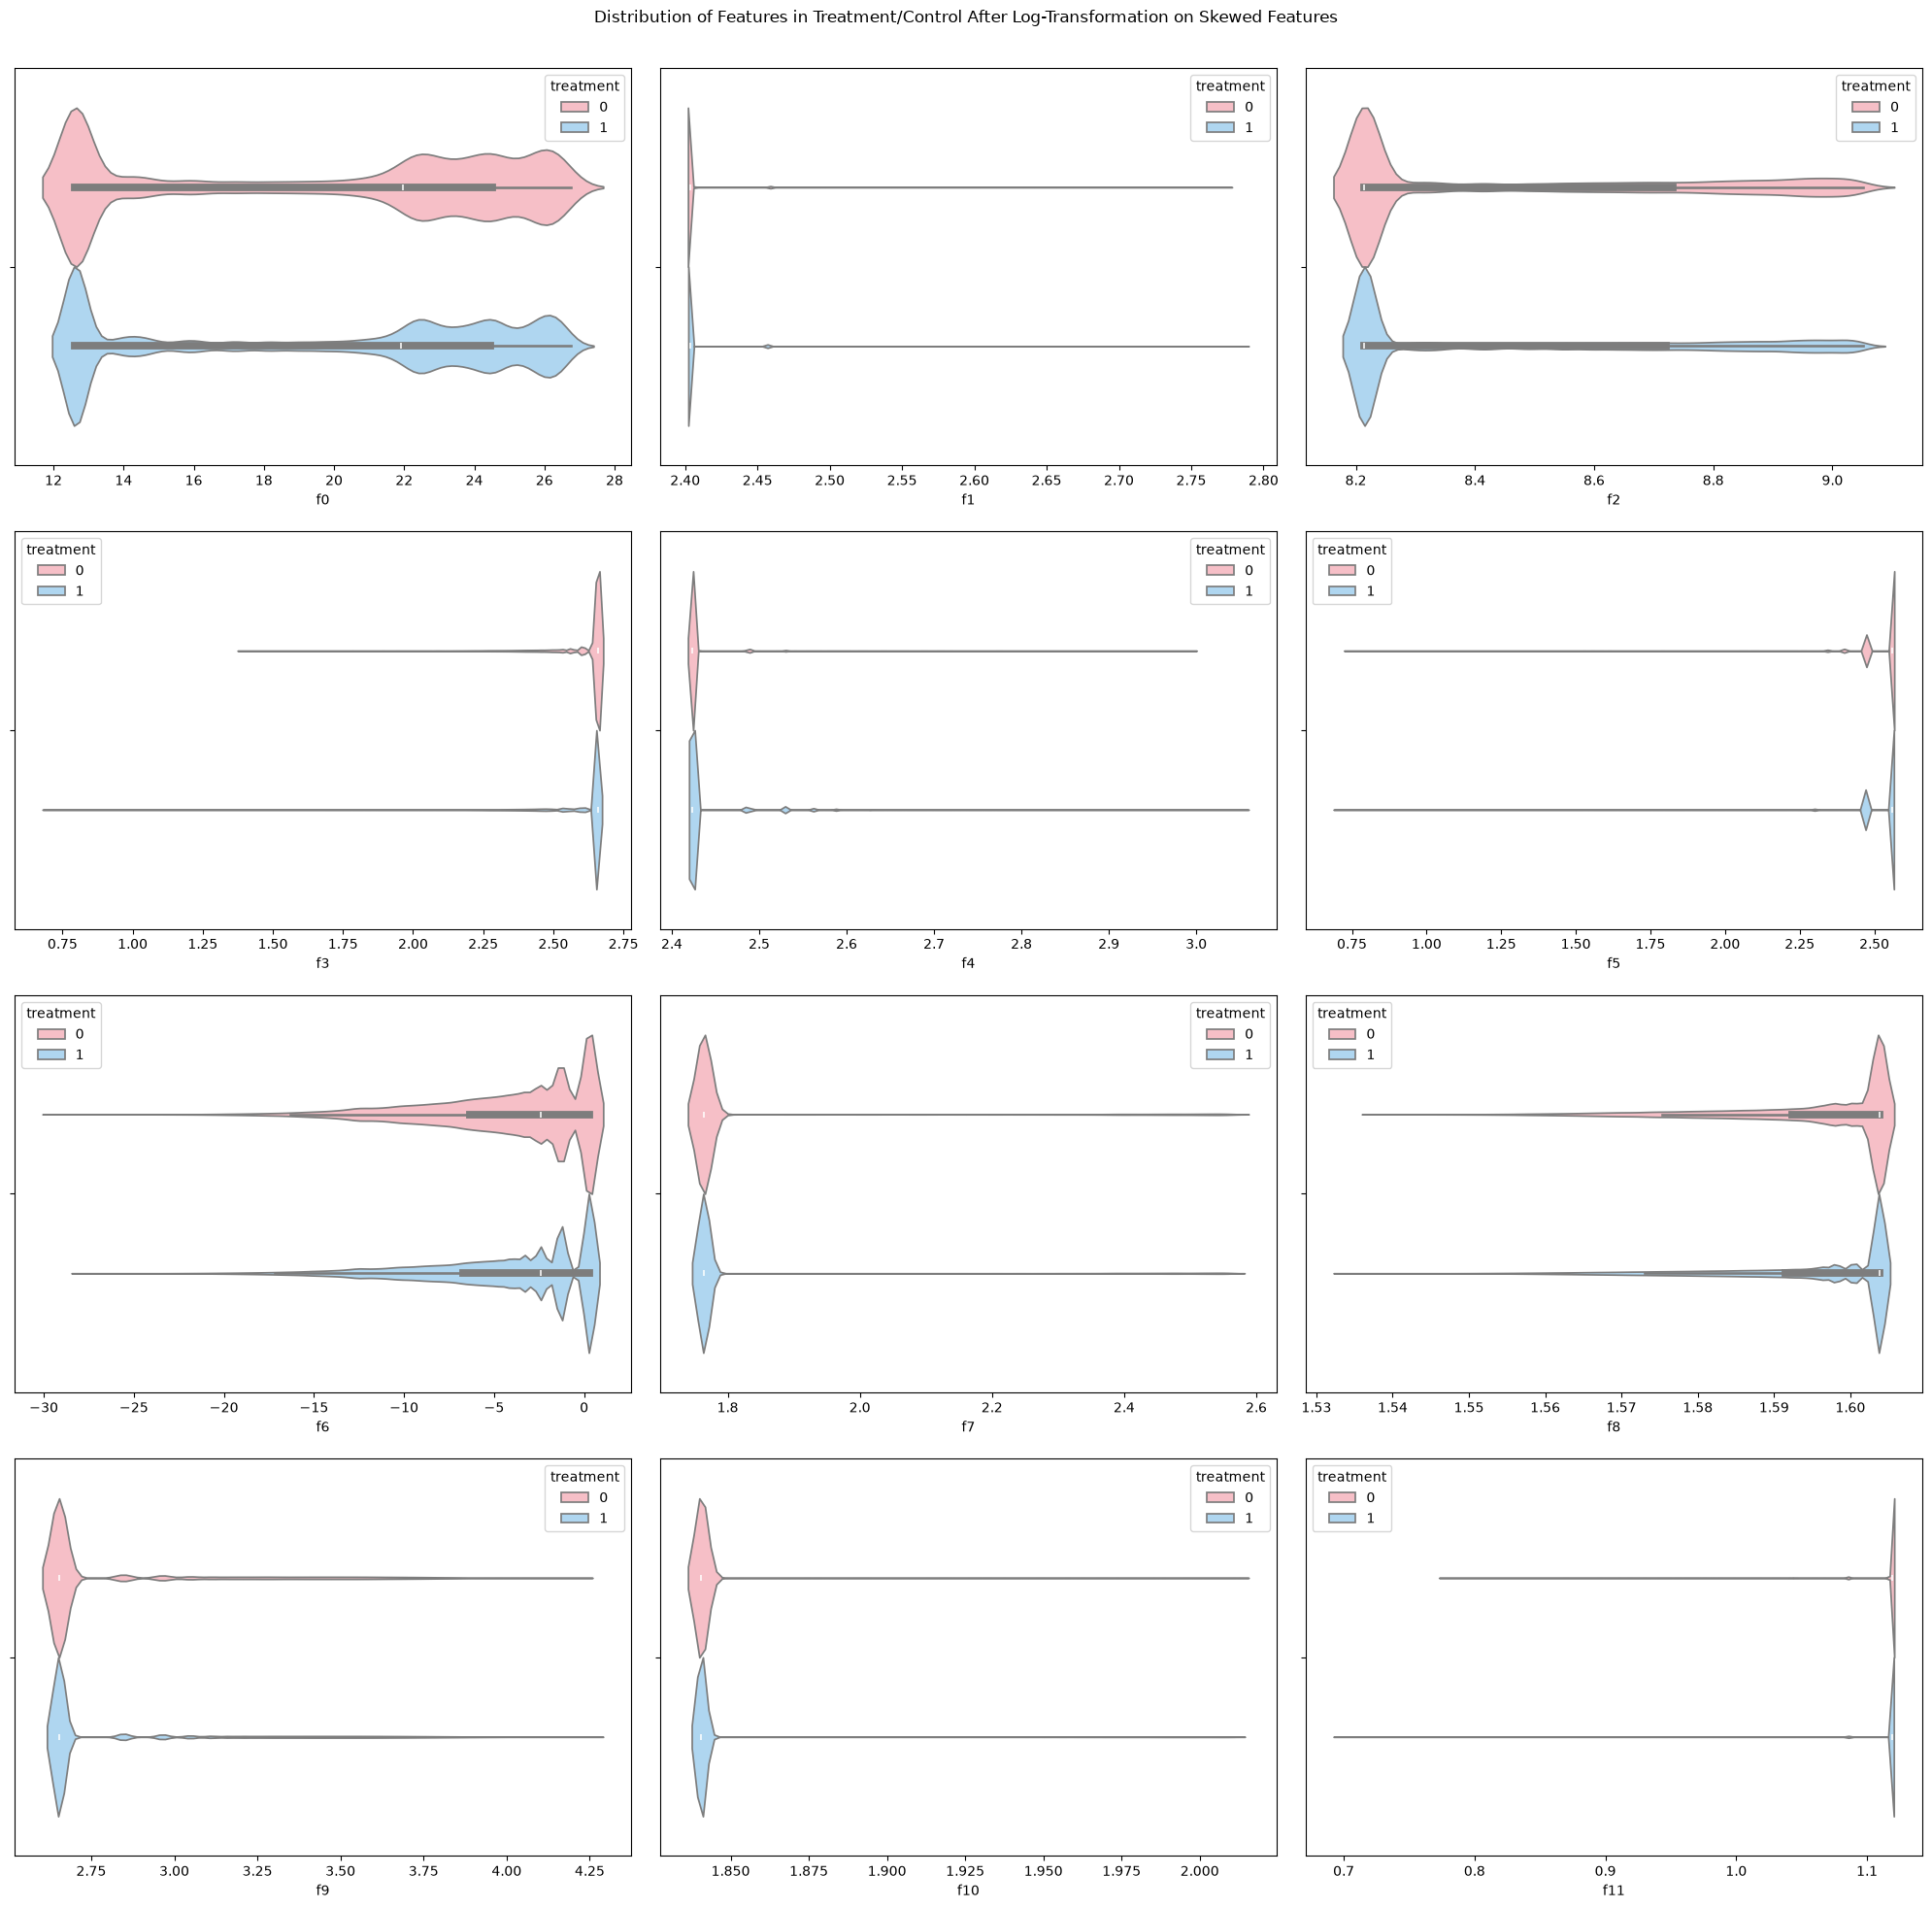

In [5]:
# Quality Check
fig, axes = plt.subplots(4, 3, figsize = (20,20))
groups = {1: "#A4D8FB", # treatment
         0: "#FFB6C1" # control
        }

df_train = pd.concat([train.X, train.treatment, train.outcome, train.secondary_outcome], axis=1)

for i, column in enumerate(train.X.columns):
    plt.subplots_adjust(top = 0.85)
    ax = sns.violinplot(data=df_train,
                x = df_train[f'f{i}'],
                hue = df_train['treatment'],
                palette = groups,
                ax = axes[(i) // 3, (i) % 3])
    ax.set_ylabel('')
fig.tight_layout(h_pad = 2)
plt.suptitle('Distribution of Features in Treatment/Control After Log-Transformation on Skewed Features')
fig.subplots_adjust(top = 0.95)

## 3. Class Imbalance: Computing scale_pos_weight

The Criteo dataset exhibits severe class imbalance in both outcome variables, with visit and conversion positive rates of approximately 4.7% and 0.3% respectively. Since these outcomes have markedly different imbalance ratios, we compute separate `scale_pos_weight` values for each:

- **Visit:** scale_pos_weight ≈ 20.26
- **Conversion:** scale_pos_weight ≈ 338.72

These values will be passed to XGBoost base learners during meta-learner training to penalize misclassification of the minority class.

In [6]:
# OUTCOME = VISIT
scale_pos_weight_visit = (df_train["visit"]==0).sum() / (df_train["visit"]==1).sum()
print(f"scale_pos_weight if outcome is visit: {scale_pos_weight_visit}")

# OUTCOME = CONVERSION
scale_pos_weight_conversion = (df_train["conversion"]==0).sum() / (df_train["conversion"]==1).sum()
print(f"scale_pos_weight if outcome is conversion: {scale_pos_weight_conversion}")

scale_pos_weight if outcome is visit: 20.25656676080289
scale_pos_weight if outcome is conversion: 338.72336811453533


In [3]:
preprocessor = Preprocessor(cfg)

train, val, test = preprocessor.split()
train, val, test = preprocessor.fit_transform(train, val, test)
preprocessor.save(train, val, test)
scale_pos_weight_visit, scale_pos_weight_conv = preprocessor.calculate_weight(train)

In [4]:
# Store scale_pos_weight for modeling
%store scale_pos_weight_visit
%store scale_pos_weight_conv

Stored 'scale_pos_weight_visit' (float64)
Stored 'scale_pos_weight_conv' (float64)


In [5]:
import json

weights = {
    "scale_pos_weight_visit": scale_pos_weight_visit,
    "scale_pos_weight_conv": scale_pos_weight_conv,
}
with open(cfg.data_dir / "scale_pos_weights.json", "w") as f:
    json.dump(weights, f, indent=2)